# Proyecto de Primer Corte — Heart Disease (Propuesta B)
## Detective Cardíaco: Analista de Riesgo Clínico

**Aprendizaje de Máquina No Supervisado — Fundamentos Probabilísticos del Machine Learning**

**Dataset:** Heart Disease (UCI Machine Learning Repository), base de Cleveland — 303 pacientes, 14 atributos clínicos.

**Cita del dataset:** Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). *Heart disease* [Data set].
UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X — Licencia CC BY 4.0.

**Escenario:** Analista de datos para una red de clínicas cardiológicas. El objetivo es entender qué evidencia clínica
resulta más informativa para distinguir presencia de enfermedad cardíaca, y cómo actualizar la sospecha diagnóstica
("prior") a medida que llega nueva evidencia ("posterior") — la analogía del detective.

**Aviso importante:** Este es un análisis académico de datos históricos con fines educativos. No constituye diagnóstico médico real.

## 0. Preparación: imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

pd.set_option('display.precision', 4)

**Carga del dataset:** utilicé `processed.cleveland.data`, el archivo específico de Cleveland (303 pacientes),
tal como exige el documento oficial del proyecto. El ZIP original de UCI contiene otras bases (Hungarian, Switzerland,
Long Beach VA) que **no se mezclan** con esta, siguiendo la convención de la literatura (solo Cleveland ha sido
ampliamente usada en investigación con este dataset).

Los nombres de columna no vienen en el archivo — se toman de `heart-disease.names`.

In [2]:
columnas = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal','num']

# Carga robusta: algunos sistemas operativos/plataformas normalizan el nombre
# del archivo reemplazando puntos internos por guiones bajos al descargar/subir.
# Se intenta primero el nombre original de UCI, y si no existe, la variante con guión bajo.
import os
posibles_nombres = ['processed.cleveland.data', 'processed_cleveland.data']
ruta_dataset = next((n for n in posibles_nombres if os.path.exists(n)), posibles_nombres[0])

df = pd.read_csv(ruta_dataset, header=None, names=columnas, na_values='?')

print(f"Archivo cargado: {ruta_dataset}")
print("Forma del dataset:", df.shape)
print("Duplicados:", df.duplicated().sum())
print("Valores faltantes por columna:")
print(df.isna().sum())

Archivo cargado: processed_cleveland.data
Forma del dataset: (303, 14)
Duplicados: 0
Valores faltantes por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


### Diccionario de variables

| Variable | Significado | Codificación |
|---|---|---|
| age | Edad en años | numérica |
| sex | Sexo | 1=hombre, 0=mujer |
| cp | Tipo de dolor de pecho | 1=típica, 2=atípica, 3=no anginoso, 4=asintomático |
| trestbps | Presión arterial en reposo (mm Hg) | numérica |
| chol | Colesterol sérico (mg/dl) | numérica |
| fbs | Azúcar en ayunas >120 mg/dl | 1=sí, 0=no |
| restecg | ECG en reposo | 0,1,2 |
| thalach | Frecuencia cardíaca máxima alcanzada | numérica |
| exang | Angina inducida por ejercicio | 1=sí, 0=no |
| oldpeak | Depresión del ST inducida por ejercicio | numérica |
| slope | Pendiente del ST en pico de ejercicio | 1,2,3 |
| ca | Nº de vasos coloreados por fluoroscopia | 0–3 |
| thal | Resultado prueba de talio | 3=normal, 6=defecto fijo, 7=defecto reversible |
| num | Variable objetivo original | 0=ausencia, 1–4=presencia (severidad) |


### Calidad de datos: valores faltantes

Se detectaron 6 pacientes con `?` en `ca` (4 casos) o `thal` (2 casos). **Decisión: eliminarlos**, en vez de
imputarlos. Justificación: ambas variables son resultados directos de procedimientos diagnósticos específicos
(fluoroscopia, prueba de talio) — no características continuas donde una imputación por media/moda sea razonable.
Imputar aquí equivaldría a inventar resultados de pruebas médicas nunca realizadas. Esta es además la práctica
estándar en la literatura publicada con este dataset (mayoría de estudios reportan n=297, no 303).

In [3]:
n_antes = len(df)
df = df.dropna(subset=['ca', 'thal']).reset_index(drop=True)
print(f"Filas antes: {n_antes} -> después: {len(df)}  (eliminadas: {n_antes-len(df)})")

Filas antes: 303 -> después: 297  (eliminadas: 6)


### Transformación `num` → `target` (binaria)

El dataset original codifica `num` con severidad (0=ausencia, 1–4=presencia con distintos grados). Según la
documentación oficial de UCI (`heart-disease.names`): *"Experiments with the Cleveland database have concentrated
on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0)"*.

Por tanto: `target = 1` si `num > 0` (cualquier nivel de severidad cuenta como presencia de enfermedad),
`target = 0` si `num == 0`.

In [4]:
df['target'] = (df['num'] > 0).astype(int)
print(pd.crosstab(df['num'], df['target']))
prior = df['target'].mean()
print(f"\nPrevalencia (prior) = P(enfermedad) = {prior:.4f} ({prior*100:.1f}%)")

target    0   1
num            
0       160   0
1         0  54
2         0  35
3         0  35
4         0  13

Prevalencia (prior) = P(enfermedad) = 0.4613 (46.1%)


## 1. Probabilidad Condicional

**Pregunta:** ¿Qué tan probable es que un paciente tenga enfermedad cardíaca dado que su dolor de pecho es de tipo asintomático?

$$P(\text{enfermedad} \mid cp=\text{asintomático}) = \frac{\text{casos con ambas condiciones}}{\text{casos con } cp=\text{asintomático}}$$

In [5]:
asintomaticos = df[df['cp'] == 4]
p_enf_dado_asint = asintomaticos['target'].mean()

print(f"P(enfermedad) [prior] = {prior:.4f}")
print(f"P(enfermedad | cp=asintomático) = {p_enf_dado_asint:.4f}  (n={len(asintomaticos)})")
print(f"Razón respecto al prior: {p_enf_dado_asint/prior:.2f}x")

print("\nP(enfermedad | tipo de dolor), las 4 categorías:")
etiquetas = {1:'típica', 2:'atípica', 3:'no anginoso', 4:'asintomático'}
tabla = df.groupby('cp')['target'].agg(['mean','count'])
tabla.index = tabla.index.map(etiquetas)
print(tabla)

P(enfermedad) [prior] = 0.4613
P(enfermedad | cp=asintomático) = 0.7254  (n=142)
Razón respecto al prior: 1.57x

P(enfermedad | tipo de dolor), las 4 categorías:
                mean  count
cp                         
típica        0.3043     23
atípica       0.1837     49
no anginoso   0.2169     83
asintomático  0.7254    142


**Hallazgo:** contra la intuición, el dolor **asintomático** (no el típico) es el que más se asocia con
enfermedad (72.5% vs 46.1% prior). En esta muestra, la categoría asintomática presenta la mayor proporción
de enfermedad de las 4 categorías de `cp`.

**Posible explicación clínica (no verificable con este dataset):** el fenómeno de isquemia silenciosa, donde
la enfermedad coronaria no siempre produce el dolor típico esperado, es consistente con este patrón — pero es
una hipótesis externa a los datos, no una conclusión que el análisis demuestre por sí solo.

**Importante:** esto es una asociación observada en un dataset transversal (pacientes ya referidos a
angiografía), no evidencia de causalidad — no se puede concluir que "la ausencia de síntoma causa" mayor
enfermedad. *Recordatorio: este es un análisis académico de datos históricos, no un diagnóstico médico real.*

## 2. Teorema de Bayes

**Pregunta:** Dado un resultado positivo en angina inducida por ejercicio, ¿cómo se actualiza la probabilidad de enfermedad?

$$P(\text{enfermedad} \mid \text{angina}) = \frac{P(\text{angina}\mid\text{enfermedad})\cdot P(\text{enfermedad})}{P(\text{angina})}$$

Se usa Bayes en vez de conteo directo porque nos obliga a pasar por la **verosimilitud** — lo que un médico
conoce de antemano sobre cómo se manifiesta la enfermedad — y desde ahí invertir hacia la pregunta diagnóstica real.

In [6]:
p_enf = df['target'].mean(); p_no = 1 - p_enf
p_ang_dado_enf = df[df['target']==1]['exang'].mean()
p_ang_dado_no = df[df['target']==0]['exang'].mean()
p_ang = p_ang_dado_enf*p_enf + p_ang_dado_no*p_no
posterior_bayes = (p_ang_dado_enf * p_enf) / p_ang

# Verificación contra cálculo directo
posterior_directo = df[df['exang']==1]['target'].mean()

print(f"P(angina | enfermedad) = {p_ang_dado_enf:.4f}  (verosimilitud)")
print(f"P(angina | no enfermedad) = {p_ang_dado_no:.4f}")
print(f"P(enfermedad | angina) via Bayes = {posterior_bayes:.4f}")
print(f"P(enfermedad | angina) directo    = {posterior_directo:.4f}")
print(f"¿Coinciden? {np.isclose(posterior_bayes, posterior_directo)}")
print(f"\nPrior {p_enf*100:.1f}% -> Posterior {posterior_bayes*100:.1f}%  ({posterior_bayes/p_enf:.2f}x)")

P(angina | enfermedad) = 0.5401  (verosimilitud)
P(angina | no enfermedad) = 0.1437
P(enfermedad | angina) via Bayes = 0.7629
P(enfermedad | angina) directo    = 0.7629
¿Coinciden? True

Prior 46.1% -> Posterior 76.3%  (1.65x)


**Hallazgo:** ambas evidencias elevan la probabilidad de enfermedad respecto al prior (46.1%): la angina
inducida por ejercicio la eleva a 76.3%, y el dolor asintomático la eleva a 72.5%. Comparar posteriores
directamente no es, sin embargo, la forma más rigurosa de decir cuál evidencia es "más fuerte" — dos
posteriores pueden diferir por razones distintas al poder informativo de la evidencia. La métrica correcta
es la razón de verosimilitud (Likelihood Ratio, LR), que calculo a continuación.

In [7]:
# Comparación rigurosa de 'fuerza de evidencia': razón de verosimilitud (Likelihood Ratio, LR),
# no simplemente el posterior final (que puede confundirse con el tamaño del grupo evaluado)
p_cp_enf = (df[df['target']==1]['cp']==4).mean()
p_cp_no = (df[df['target']==0]['cp']==4).mean()
LR_cp = p_cp_enf / p_cp_no

LR_exang = p_ang_dado_enf / p_ang_dado_no

print(f"LR(cp=asintomático) = P(cp=4|enf)/P(cp=4|no enf) = {LR_cp:.3f}")
print(f"LR(exang=angina)    = P(exang=1|enf)/P(exang=1|no enf) = {LR_exang:.3f}")
print(f"\n¿Cuál aporta más evidencia? {'exang' if LR_exang>LR_cp else 'cp'} (mayor razón de verosimilitud)")

LR(cp=asintomático) = P(cp=4|enf)/P(cp=4|no enf) = 3.084
LR(exang=angina)    = P(exang=1|enf)/P(exang=1|no enf) = 3.758

¿Cuál aporta más evidencia? exang (mayor razón de verosimilitud)


**Conclusión (respuesta rigurosa a la comparación de evidencias):** LR(exang)=3.76 > LR(cp=asintomático)=3.08.
Con la métrica correcta (razón de verosimilitud), la angina inducida por ejercicio **sí** aporta más
evidencia que el tipo de dolor de pecho — no por casualidad, sino porque separa mejor a los dos grupos en
términos relativos. Esto confirma la intuición original, pero ahora con el fundamento estadístico adecuado
en vez de solo comparar los posteriores finales.

## 3. Verosimilitud / Máxima Verosimilitud (MLE)

**Pregunta:** ¿Cómo se ven las distribuciones de colesterol en pacientes con y sin enfermedad, ajustadas por MLE?

Para una Gaussiana, los estimadores MLE tienen forma cerrada: $\hat\mu = \bar x$, $\hat\sigma^2 = \frac{1}{n}\sum(x_i-\bar x)^2$
— la media y varianza muestral **son** los parámetros de máxima verosimilitud, no una aproximación.

In [8]:
chol_enf = df[df['target']==1]['chol']
chol_sano = df[df['target']==0]['chol']

mu_enf, sigma_enf = chol_enf.mean(), chol_enf.std(ddof=0)
mu_sano, sigma_sano = chol_sano.mean(), chol_sano.std(ddof=0)

print(f"Enfermos (n={len(chol_enf)}): mu={mu_enf:.2f}, sigma={sigma_enf:.2f}, sigma^2={sigma_enf**2:.2f}")
print(f"Sanos    (n={len(chol_sano)}): mu={mu_sano:.2f}, sigma={sigma_sano:.2f}, sigma^2={sigma_sano**2:.2f}")
print(f"Diferencia de medias: {mu_enf-mu_sano:.2f} mg/dl")

sw_enf = stats.shapiro(chol_enf); sw_sano = stats.shapiro(chol_sano)
print(f"\nShapiro-Wilk enfermos: p={sw_enf.pvalue:.4f}  |  sanos: p={sw_sano.pvalue:.4f}")

Enfermos (n=137): mu=251.85, sigma=49.50, sigma^2=2450.08
Sanos    (n=160): mu=243.49, sigma=53.59, sigma^2=2871.81
Diferencia de medias: 8.36 mg/dl

Shapiro-Wilk enfermos: p=0.4319  |  sanos: p=0.0000


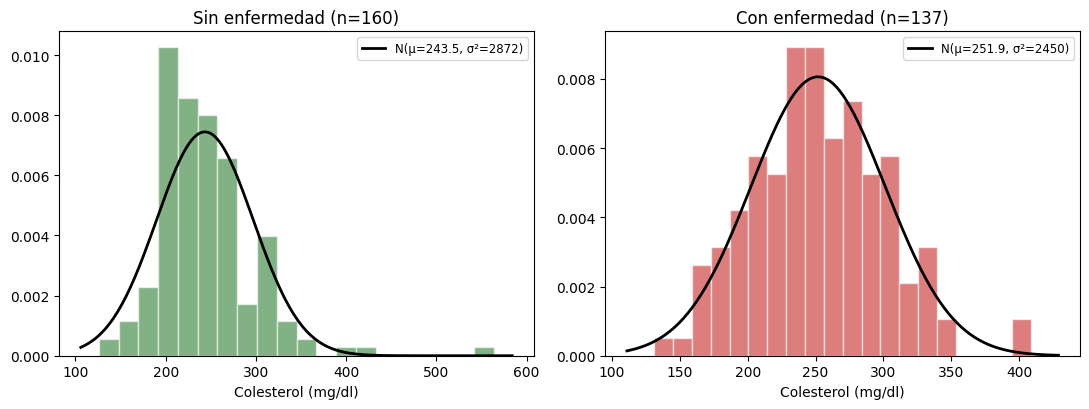

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
for ax, data, mu, sigma, titulo, color in [
    (axes[0], chol_sano, mu_sano, sigma_sano, f'Sin enfermedad (n={len(chol_sano)})', '#2E7D32'),
    (axes[1], chol_enf, mu_enf, sigma_enf, f'Con enfermedad (n={len(chol_enf)})', '#C62828')]:
    ax.hist(data, bins=20, density=True, alpha=0.6, color=color, edgecolor='white')
    x = np.linspace(data.min()-20, data.max()+20, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k-', lw=2, label=f'N(μ={mu:.1f}, σ²={sigma**2:.0f})')
    ax.set_title(titulo); ax.set_xlabel('Colesterol (mg/dl)'); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Hallazgo:** diferencia de medias pequeña (8.4 mg/dl). El test de normalidad se rechaza para el grupo
sano (p<0.0001) por una cola derecha pesada (outliers >400 mg/dl) — limitación documentada, no oculta. El grupo
enfermo sí es compatible con Gaussiana (p=0.43).

## 4. Distribuciones Paramétricas

**Pregunta:** ¿Qué distribución corresponde a `sex`, `cp`, `chol`, `thalach`?

In [10]:
print("=== sex (Bernoulli) ===")
print(df['sex'].value_counts(normalize=True).sort_index())

print("\n=== cp (Categórica) ===")
print(df['cp'].value_counts(normalize=True).sort_index())

print("\n=== thalach (Gaussiana aproximada) ===")
sw_th = stats.shapiro(df['thalach'])
print(f"mu={df['thalach'].mean():.2f}, sigma={df['thalach'].std(ddof=0):.2f}, Shapiro p={sw_th.pvalue:.4f}")
print(f"Asimetría: {stats.skew(df['thalach']):.4f}")

print("\n=== chol (Gaussiana aproximada, con reservas) ===")
sw_ch = stats.shapiro(df['chol'])
print(f"Shapiro p={sw_ch.pvalue:.4f}  (rechaza normalidad estricta, cola derecha pesada)")


=== sex (Bernoulli) ===
sex
0.0    0.3232
1.0    0.6768
Name: proportion, dtype: float64

=== cp (Categórica) ===
cp
1.0    0.0774
2.0    0.1650
3.0    0.2795
4.0    0.4781
Name: proportion, dtype: float64

=== thalach (Gaussiana aproximada) ===
mu=149.60, sigma=22.90, Shapiro p=0.0001
Asimetría: -0.5338

=== chol (Gaussiana aproximada, con reservas) ===
Shapiro p=0.0000  (rechaza normalidad estricta, cola derecha pesada)


**Justificación:**
- `sex`: Bernoulli(p=0.68) — 2 valores posibles, encaja por definición exacta, no es una aproximación.
- `cp`: Categórica — 4 valores discretos sin escala numérica real entre categorías (no es lo mismo pasar de
  típica a atípica que de no-anginoso a asintomático), encaja por definición exacta.
- `chol`, `thalach`: Gaussiana **aproximada**. Es importante ser precisos sobre qué significa esto: **no estoy
  afirmando que los datos sean perfectamente normales** — el test de Shapiro-Wilk rechaza formalmente la
  normalidad en ambas (p<0.0001 y p=0.0001 respectivamente). Reconozco ese resultado sin ocultarlo.

  Sin embargo, sigo usando la aproximación Gaussiana porque: (1) con n≈300, Shapiro-Wilk es muy sensible
  y detecta desviaciones pequeñas que no son necesariamente relevantes en la práctica; (2) el ajuste visual
  (histograma + curva, ver Concepto 3) es razonable en el cuerpo central de ambas distribuciones, con la
  principal desviación concentrada en la cola derecha de `chol`; y (3) el objetivo del proyecto en este
  punto es estimar parámetros interpretables (media, varianza) para comparar grupos, no lograr un ajuste
  probabilístico perfecto — la Gaussiana cumple ese propósito con una limitación documentada, no oculta.

## 5. Esperanza y Varianza

**Pregunta:** ¿Cuál es la esperanza y varianza de la frecuencia cardíaca máxima (`thalach`), separando por enfermedad?

In [11]:
th_enf = df[df['target']==1]['thalach']
th_sano = df[df['target']==0]['thalach']

E_enf, Var_enf = th_enf.mean(), th_enf.var(ddof=0)
E_sano, Var_sano = th_sano.mean(), th_sano.var(ddof=0)

print(f"Con enfermedad (n={len(th_enf)}):  E[X]={E_enf:.2f}  Var(X)={Var_enf:.2f}")
print(f"Sin enfermedad (n={len(th_sano)}): E[X]={E_sano:.2f}  Var(X)={Var_sano:.2f}")
print(f"Diferencia de esperanzas: {E_sano-E_enf:.2f} lpm")

t_stat, p_val = stats.ttest_ind(th_sano, th_enf, equal_var=False)
print(f"Test t de Welch: t={t_stat:.3f}, p={p_val:.2e}")

Con enfermedad (n=137):  E[X]=139.11  Var(X)=512.01
Sin enfermedad (n=160): E[X]=158.58  Var(X)=360.38
Diferencia de esperanzas: 19.47 lpm
Test t de Welch: t=7.929, p=6.11e-14


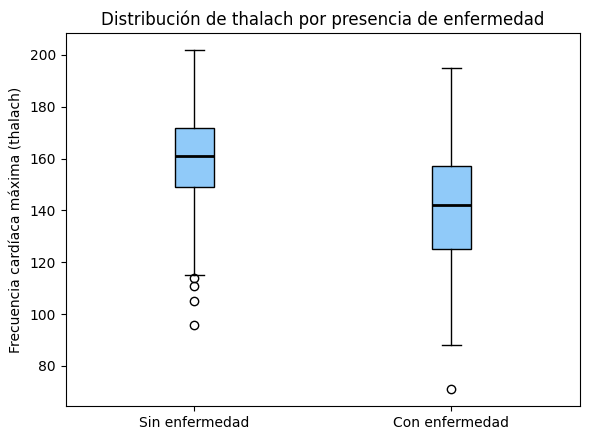

In [12]:
fig, ax = plt.subplots(figsize=(6,4.5))
ax.boxplot([th_sano, th_enf], tick_labels=['Sin enfermedad','Con enfermedad'],
           patch_artist=True, boxprops=dict(facecolor='#90CAF9'), medianprops=dict(color='black', linewidth=2))
ax.set_ylabel('Frecuencia cardíaca máxima (thalach)')
ax.set_title('Distribución de thalach por presencia de enfermedad')
plt.tight_layout(); plt.show()

**Hallazgo:** la diferencia de `thalach` entre grupos es estadísticamente muy sólida (p≈6×10⁻¹⁴, test de
Welch): los sanos alcanzan en promedio 19.5 lpm más que los enfermos.

**Antes de afirmar que esta es "la variable que más discrimina" del proyecto**, conviene verificarlo con
una comparación formal entre todas las variables numéricas, en vez de basarse solo en la magnitud de un
resultado aislado. Por eso calculo a continuación el tamaño de efecto (Cohen's d) para las 6 variables
numéricas del dataset.

**Nota metodológica — Cohen's d (no es uno de los 11 conceptos oficiales; análisis complementario):**

El problema que resuelve: comparar `thalach` (se diferencia en 19.5 lpm entre grupos) contra `chol`
(se diferencia en 8.4 mg/dl) directamente no tiene sentido — son unidades distintas, como comparar
metros con kilos.

Cohen's d convierte cada diferencia a una escala común: **cuántas desviaciones estándar de distancia
hay entre los dos grupos**.

$$d = \frac{\bar{x}_{enf} - \bar{x}_{sano}}{s_{pooled}} \qquad s_{pooled} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

donde $s_{pooled}$ es la desviación estándar combinada de ambos grupos. Una diferencia absoluta
pequeña puede ser un efecto *grande* si la variable varía poco entre personas (caso `thalach`), y una
diferencia absoluta grande puede ser un efecto *pequeño* si la variable varía mucho (caso `chol`).

**Convención estándar de interpretación:** |d|≈0.2 = efecto pequeño, ≈0.5 = mediano, ≥0.8 = grande.

In [13]:
# Comparación formal entre variables: ¿cuál discrimina más? No basta con mirar
# una sola variable (thalach) y asumir que es 'la más fuerte' -- calculamos el
# tamaño de efecto (Cohen's d) para TODAS las variables numéricas, con la misma métrica.
numericas_todas = ['age','trestbps','chol','thalach','oldpeak','ca']
resultados_d = []
for var in numericas_todas:
    g1 = df[df['target']==1][var]; g0 = df[df['target']==0][var]
    n1, n0 = len(g1), len(g0)
    s1, s0 = g1.std(ddof=1), g0.std(ddof=1)
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n0-1)*s0**2) / (n1+n0-2))
    d = (g1.mean() - g0.mean()) / s_pooled
    resultados_d.append((var, g1.mean(), g0.mean(), d))

tabla_d = pd.DataFrame(resultados_d, columns=['variable','media_enf','media_sano','cohen_d'])
tabla_d['abs_d'] = tabla_d['cohen_d'].abs()
tabla_d = tabla_d.sort_values('abs_d', ascending=False).drop(columns='abs_d').reset_index(drop=True)
print(tabla_d.round(3))

   variable  media_enf  media_sano  cohen_d
0        ca      1.146       0.275    1.045
1   oldpeak      1.589       0.599    0.936
2   thalach    139.109     158.581   -0.935
3       age     56.759      52.644    0.466
4  trestbps    134.635     129.175    0.311
5      chol    251.854     243.494    0.161


**Conclusión:** con la métrica formal (Cohen's d), el ranking real es:

| Variable | \|Cohen's d\| |
|---|---|
| **ca** | **1.045** |
| oldpeak | 0.936 |
| thalach | 0.935 |
| age | 0.466 |
| trestbps | 0.311 |
| chol | 0.161 |

**`ca` (número de vasos coloreados por fluoroscopia) es el discriminador univariado más fuerte del dataset**
— muy cerca de `oldpeak` y `thalach` (los tres por encima de 0.9, un efecto grande según convenciones
estándar: |d|>0.8 = efecto grande). `chol` es, en cambio, el discriminador más débil del grupo,
consistente con el bajo valor de KL del Concepto 11.

## 6. Independencia y Correlación

**Pregunta A:** ¿Sexo y enfermedad son independientes? **Pregunta B:** ¿Hay multicolinealidad entre variables numéricas?

In [14]:
tabla_cont = pd.crosstab(df['sex'], df['target'])
tabla_cont.index = ['Mujer','Hombre']; tabla_cont.columns = ['Sin enf.','Con enf.']
print(tabla_cont)

chi2, p_val, dof, expected = stats.chi2_contingency(tabla_cont)
n = tabla_cont.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla_cont.shape)-1)))
print(f"\nChi2={chi2:.4f}, p={p_val:.2e}, Cramér's V={cramers_v:.4f}")
print(f"Frecuencia esperada mínima: {expected.min():.1f} (supuesto >=5: {'OK' if expected.min()>=5 else 'VIOLADO'})")

print("\nP(enfermedad|sexo):")
print(df.groupby('sex')['target'].mean().rename(index={0:'Mujer',1:'Hombre'}))

        Sin enf.  Con enf.
Mujer         71        25
Hombre        89       112

Chi2=21.8516, p=2.95e-06, Cramér's V=0.2712
Frecuencia esperada mínima: 44.3 (supuesto >=5: OK)

P(enfermedad|sexo):
sex
Mujer     0.2604
Hombre    0.5572
Name: target, dtype: float64


            age  trestbps   chol  thalach  oldpeak     ca
age       1.000     0.290  0.203   -0.395    0.197  0.362
trestbps  0.290     1.000  0.132   -0.049    0.191  0.098
chol      0.203     0.132  1.000   -0.000    0.039  0.116
thalach  -0.395    -0.049 -0.000    1.000   -0.348 -0.269
oldpeak   0.197     0.191  0.039   -0.348    1.000  0.294
ca        0.362     0.098  0.116   -0.269    0.294  1.000


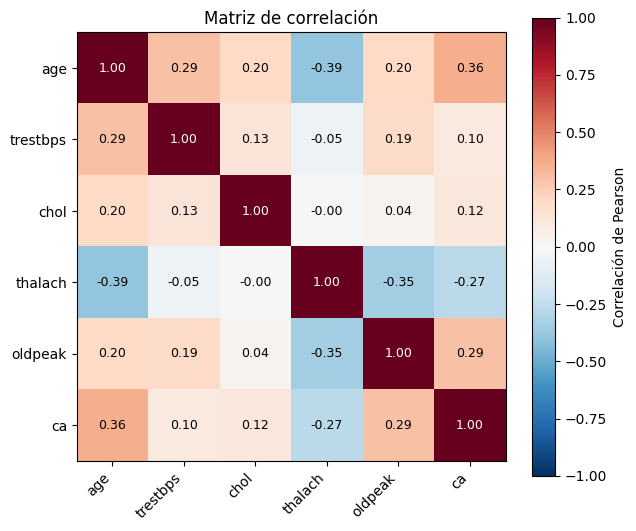

In [15]:
numericas = ['age','trestbps','chol','thalach','oldpeak','ca']
corr = df[numericas].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6.5,5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numericas))); ax.set_xticklabels(numericas, rotation=45, ha='right')
ax.set_yticks(range(len(numericas))); ax.set_yticklabels(numericas)
for i in range(len(numericas)):
    for j in range(len(numericas)):
        ax.text(j,i,f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                 color='white' if abs(corr.iloc[i,j])>0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='Correlación de Pearson')
plt.title('Matriz de correlación'); plt.tight_layout(); plt.show()

**Hallazgo:** sexo y enfermedad **no son independientes** (χ²=21.85, p=2.95×10⁻⁶), con efecto
moderado (Cramér's V=0.27): 55.7% de hombres vs 26.0% de mujeres con enfermedad. No hay multicolinealidad
severa entre variables numéricas (máx. |r|=0.395, thalach vs age).

## 7. Prior y Posterior — Actualización Bayesiana Secuencial

**Pregunta:** partiendo del prior poblacional, ¿cómo se actualiza la probabilidad con 3 evidencias sucesivas
(cp=asintomático, exang=angina, thal=anormal)? **¿Importa el orden?**

In [16]:
df['E_cp'] = (df['cp']==4); df['E_exang'] = (df['exang']==1); df['E_thal'] = df['thal'].isin([6,7])
evidencias = {'cp':'E_cp', 'exang':'E_exang', 'thal':'E_thal'}

def bayes_update(prior_actual, p1, p0):
    p_ev = p1*prior_actual + p0*(1-prior_actual)
    return (p1*prior_actual)/p_ev

def naive_secuencial(orden):
    p = prior
    for nombre in orden:
        col = evidencias[nombre]
        p1 = df[df['target']==1][col].mean(); p0 = df[df['target']==0][col].mean()
        p = bayes_update(p, p1, p0)
    return p

def filtrado_real(orden):
    sub = df.copy()
    trace = [(len(sub), prior)]
    for nombre in orden:
        sub = sub[sub[evidencias[nombre]]]
        trace.append((len(sub), sub['target'].mean() if len(sub)>0 else np.nan))
    return trace

orden_A = ['cp','exang','thal']; orden_B = ['thal','exang','cp']

print("Naive Bayes secuencial:")
print(f"  Orden A -> posterior final: {naive_secuencial(orden_A):.4f}")
print(f"  Orden B -> posterior final: {naive_secuencial(orden_B):.4f}")

print("\nFiltrado real (conjunto exacto), Orden A:")
for nombre,(n,p) in zip(['prior']+orden_A, filtrado_real(orden_A)):
    print(f"  {nombre}: n={n}, P={p:.4f}" if not np.isnan(p) else f"  {nombre}: n={n}")

print("\nFiltrado real (conjunto exacto), Orden B:")
for nombre,(n,p) in zip(['prior']+orden_B, filtrado_real(orden_B)):
    print(f"  {nombre}: n={n}, P={p:.4f}" if not np.isnan(p) else f"  {nombre}: n={n}")

Naive Bayes secuencial:
  Orden A -> posterior final: 0.9723
  Orden B -> posterior final: 0.9723

Filtrado real (conjunto exacto), Orden A:
  prior: n=297, P=0.4613
  cp: n=142, P=0.7254
  exang: n=78, P=0.8718
  thal: n=57, P=0.9298

Filtrado real (conjunto exacto), Orden B:
  prior: n=297, P=0.4613
  thal: n=133, P=0.7519
  exang: n=66, P=0.8939
  cp: n=57, P=0.9298


**Aclaración:** 97.2% y 93.0% no son resultados contradictorios ni un error de cálculo — corresponden a dos
métodos con supuestos distintos (independencia condicional asumida vs. datos reales filtrados conjuntamente).
La brecha entre ambos (~4.2 puntos porcentuales) puede reflejar dependencia entre las evidencias y
variabilidad muestral. El subgrupo final del filtrado real es pequeño (n=57), por lo que no debe
interpretarse como una medición exacta de cuánto se desvía el supuesto de independencia.

## 8-9. Entropía y Entropía Condicional

**Pregunta:** ¿Cuánta incertidumbre hay en `target`? ¿Cuánto se reduce al conocer `cp`?

$$H(X) = -\sum_i P(x_i)\log_2 P(x_i) \qquad H(X\mid Y) = \sum_y P(y)\,H(X\mid Y=y)$$

In [17]:
def entropia(probs):
    probs = np.array(probs); probs = probs[probs>0]
    return -np.sum(probs*np.log2(probs))

p1 = df['target'].mean(); p0 = 1-p1
H_target = entropia([p0,p1])
print(f"H(target) = {H_target:.4f} bits  (máx teórico = 1.0)")

H_cond = 0
for v,g in df.groupby('cp'):
    pv = len(g)/len(df)
    p1g = g['target'].mean(); p0g = 1-p1g
    H_cond += pv*entropia([p0g,p1g])
print(f"H(target|cp) = {H_cond:.4f} bits")
print(f"Ganancia de información = {H_target-H_cond:.4f} bits ({(H_target-H_cond)/H_target*100:.1f}%)")

H(target) = 0.9957 bits  (máx teórico = 1.0)
H(target|cp) = 0.7985 bits
Ganancia de información = 0.1972 bits (19.8%)


**Hallazgo (respuesta a pregunta de defensa oral #2):** H(target)=0.9957 bits, casi el máximo teórico
(clases casi balanceadas: 46.1% vs 53.9%). H(target|cp)=0.7985 bits — conocer `cp` reduce la incertidumbre en
19.8%. Clínicamente: el tipo de dolor es señal útil pero parcial, no resuelve el diagnóstico por sí solo.

## 10. Entropía Cruzada

**Pregunta:** ¿Qué tan bien predice un clasificador simple (regresión logística) la enfermedad?

### Nota metodológica — ¿por qué nats y no bits en esta sección?

A diferencia de Entropía y Entropía condicional (Conceptos 8-9), donde uso **bits** por su interpretabilidad
directa (número de preguntas sí/no para resolver la incertidumbre), aquí reporto en **nats** por dos razones:

1. **Es la unidad nativa de la herramienta.** `sklearn.metrics.log_loss()` usa logaritmo natural por convención
   estándar de machine learning (la misma que PyTorch y TensorFlow). Reportar en nats evita una conversión
   innecesaria y mantiene la cifra directamente trazable a la salida de la librería.
2. **Es consistente con la referencia del curso.** El informe de ejemplo del profesor (caso TelecomCo/Churn)
   reporta explícitamente en nats: *"0.51 nats de log-loss en prueba (holdout) vs H=0.59 nats"* — incluso
   mientras usa bits en su sección de Entropía. Sigo el mismo patrón.

**Decisión:** no convierto el modelo a bits. Cuando se necesita comparar contra la entropía baseline
H(target) (calculada en bits en la sección anterior), convierto únicamente esa referencia puntual a nats
para la comparación local, sin alterar el resto del proyecto. Esto es una decisión deliberada y documentada,
no una inconsistencia entre secciones.

In [18]:
categoricas = ['cp','restecg','slope','thal']
numericas_mod = ['age','sex','trestbps','chol','fbs','thalach','exang','oldpeak','ca']
X = pd.get_dummies(df[categoricas+numericas_mod], columns=categoricas, drop_first=True)
y = df['target']

# Se utiliza una partición 75/25 estratificada: 75% de los datos se destinan al entrenamiento y 25% a la prueba.
# Esto permite reservar datos independientes para evaluar el modelo, manteniendo la proporción de las clases en
# ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train); X_test_sc = scaler.transform(X_test)

modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_sc, y_train)

p_train = modelo.predict_proba(X_train_sc)[:,1]
p_test = modelo.predict_proba(X_test_sc)[:,1]

ce_train = log_loss(y_train, p_train); ce_test = log_loss(y_test, p_test)
print(f"Entropía cruzada train: {ce_train:.4f} nats")
print(f"Entropía cruzada test:  {ce_test:.4f} nats")
print(f"H(target) baseline en nats: {H_target*np.log(2):.4f}")
print(f"Accuracy test: {accuracy_score(y_test, p_test>0.5):.4f}")
print(f"AUC test: {roc_auc_score(y_test, p_test):.4f}")

Entropía cruzada train: 0.3342 nats
Entropía cruzada test:  0.3215 nats
H(target) baseline en nats: 0.6901
Accuracy test: 0.8533
AUC test: 0.9357


**Hallazgo:** la entropía cruzada de test (0.322 nats) es menos de la mitad del baseline H(target) en
nats (0.690) — una reducción aproximada del **53% en la entropía cruzada respecto al baseline**. Es
importante ser precisos con la terminología: la entropía cruzada del modelo no es literalmente "la
incertidumbre restante" — es una medida del error de predicción del modelo, y actúa como una **cota
superior** de la verdadera entropía condicional H(target | todas las variables). Que esté muy por debajo
del baseline es evidencia de que el modelo captura señal real, no solo azar. Las pérdidas de entrenamiento y prueba son similares (0.334 vs. 0.322), sin una brecha evidente
en este holdout. AUC=0.936, accuracy=85.3%.

## 11. Divergencia KL

**Pregunta (defensa oral #3):** ¿Qué tan distinguibles son las distribuciones de colesterol entre pacientes
con y sin enfermedad?

$$D_{KL}(P\|Q) = \sum_i P(x_i)\log_2\frac{P(x_i)}{Q(x_i)}$$

In [19]:
chol_enf = df[df['target']==1]['chol'].values
chol_sano = df[df['target']==0]['chol'].values

n_bins = 15
edges = np.linspace(min(chol_enf.min(),chol_sano.min()), max(chol_enf.max(),chol_sano.max()), n_bins+1)
h_enf,_ = np.histogram(chol_enf, bins=edges); h_sano,_ = np.histogram(chol_sano, bins=edges)

eps = 1e-6  # suavizado de Laplace para evitar log(0)
p_enf_s = (h_enf+eps)/(h_enf+eps).sum(); p_sano_s = (h_sano+eps)/(h_sano+eps).sum()

def kl_div(p,q): return np.sum(p*np.log2(p/q))

kl_es = kl_div(p_enf_s, p_sano_s)
kl_se = kl_div(p_sano_s, p_enf_s)
print(f"D_KL(Enfermos||Sanos) = {kl_es:.4f} bits")
print(f"D_KL(Sanos||Enfermos) = {kl_se:.4f} bits  (KL no es simétrica)")

D_KL(Enfermos||Sanos) = 0.1722 bits
D_KL(Sanos||Enfermos) = 0.3532 bits  (KL no es simétrica)


**Hallazgo (respuesta a defensa oral #3):** D_KL(Enfermos‖Sanos)=0.172 bits, D_KL(Sanos‖Enfermos)=0.353
bits — la asimetría confirma que KL no es una distancia simétrica, y que la dirección de comparación
importa (ver interpretación de la asimetría más arriba). Ambos valores son pequeños: para dar una idea de
escala, son una fracción menor de H(target)=0.9957 bits, aunque esta comparación es informal (KL mide
divergencia entre las distribuciones de colesterol condicionadas al diagnóstico, mientras que H(target)
mide la incertidumbre de la variable objetivo; comparten unidad —bits— pero no hay una cota teórica que
relacione directamente una con la otra).

La evidencia más sólida para responder la pregunta viene de mis propios resultados, no de una escala externa: el colesterol tiene el Cohen's d más bajo de todas las variables numéricas comparadas (0.161, Concepto 6) y la diferencia de medias más pequeña entre grupos (Concepto 3). La divergencia KL confirma, con una métrica distinta y complementaria, la misma conclusión: el colesterol por sí solo es el discriminador más débil del proyecto entre pacientes con y sin enfermedad.

## Resumen ejecutivo — Detective Case File

```
CASO: HEART DISEASE — CLEVELAND (n=297 tras limpieza)

Prior: P(enfermedad) = 46.1%

Evidencia 1 (cp=asintomático):      Posterior = 72.5%  (n=142, LR=3.08)
Evidencia 2 (+exang=angina):        Posterior = 87.2%  (n=78)
Evidencia 3 (+thal=anormal):        Posterior FINAL = 93.0%  (n=57)
[Orden no afecta el resultado final; sí afecta posteriores intermedios]

Entropía H(target) = 0.9957 bits (casi máxima, clases balanceadas)
Entropía condicional H(target|cp) = 0.7985 bits (19.8% de ganancia)
Entropía cruzada del modelo (test) = 0.3215 nats (53% de reducción vs baseline, en nats)
KL colesterol enfermos vs sanos = 0.172-0.353 bits (discriminador débil, confirmado por Cohen's d=0.161)

Hallazgos principales:
1. ca (vasos coloreados) es el discriminador univariado más fuerte (Cohen's d=1.045),
   seguido muy de cerca por oldpeak (d=0.936) y thalach (d=0.935)
2. La combinación de evidencias (Bayes secuencial) es más informativa que cualquier variable sola
3. El colesterol, contrario a la intuición popular, es el discriminador más débil (d=0.161, KL bajo)

Números críticos para la defensa oral:
1. Posterior final secuencial: 93.0% (n=57), invariante al orden
2. H(target)=0.9957 vs H(target|cp)=0.7985 bits
3. D_KL(Enfermos||Sanos)=0.172 bits
```
